## **Spectroscopic IROS Reconstruction**

In [1]:
from pathlib import Path
from typing import Any, Callable

import numpy as np
from numpy.typing import NDArray
from astropy.io.fits import FITS_rec
from tqdm import tqdm

from bloodmoon.types import CoordEquatorial
from bloodmoon.mask import CodedMaskCamera, codedmask
from bloodmoon.io import simulation_files
import darksun as ds
from darksun.data import Log
from darksun.benchmarking import source_catalogue_data
from darksun.data import DataLoader, CatalogueLoader


from IROSrec.handle import config_dirpaths
from IROSrec.iros.optim import iros_singleCAM
from IROSrec.iros.procedure import run_IROS, get_sources_database

import imgmaker as mgm

ds.show.set_figures_darkbkg()

In [2]:
MASK_FITS: str = "mask_NTHT_20250725.fits"
UPS_X, UPS_Y = 2, 1

SKYFIELD: str = "GalacticCentre"
DATA_FITS: str = "galctr_rxte-sax_mask_050_1040x17_2-50keV_1ks"

ID_CAMERA_A: str = "cam1a"
DATASET: str = "reconstructed"

PSFY = mgm.config_psfy_flag(DATASET)

In [3]:
MASK_PATH, SIMUL_DATA_PATH, _ = config_dirpaths(
    mask=MASK_FITS,
    skyfield=SKYFIELD,
    simul=DATA_FITS,
)
OUT_RESULTS_PATH = mgm.config_savedata_to()

wfm: CodedMaskCamera = codedmask(MASK_PATH, UPS_X, UPS_Y)

filepaths: dict[str, dict[str, Path]] = simulation_files(SIMUL_DATA_PATH)
sdlA = ds.get_data(filepaths[ID_CAMERA_A][DATASET])
catA = ds.get_catalogue(filepaths[ID_CAMERA_A]['sources'])
# sdlB = ds.get_data(filepaths[ID_CAMERA_B][DATASET])
# catB = ds.get_catalogue(filepaths[ID_CAMERA_B]['sources'])

In [4]:
# - data gathering from specific direction
#   NOTE: Filtering the whole photons list by specific incoming direction associated with a source
#         is just a way to reduce the computational cost of data handling operations.
#         Since we are dealing with a WM sim, we know the actual photons directions. In a real
#         obs this info is lost in the encoding phase (hence, we can only filter for energy).
#   NOTE: If the spectroscopic analysis is performed AFTER a first IROS reconstruction, the sources
#         coords in the camera local-frame are known, and can be utilised in the sky image to select
#         subsections of the skymap for the spectroscopic analysis (e.g., as an external trigger).

def get_source_coords(sourceID: str, catalogue: CatalogueLoader) -> CoordEquatorial:
    """Extracts the source RA/Dec coords from catalogue."""
    data = source_catalogue_data(sourceID, catalogue.DLdata)
    return CoordEquatorial(data['RA'], data['DEC'])

def select_target_srcs(
    photons: FITS_rec,
    srcIDs: str | tuple[str, ...],
    catalogue: CatalogueLoader,
) -> FITS_rec:
    """Filters the input photon list for the given sources equatorial coords."""
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    coords = tuple(get_source_coords(src, catalogue) for src in srcIDs_)
    phs = ds.select_source_photons(coords, photons, False)
    return phs

In [5]:
# - energy bands scheduler and filtering

type EnergyRange = tuple[float, float]
type EnergySchedule = list[EnergyRange]

def select_eband_phs(photons: FITS_rec, eband: EnergyRange) -> FITS_rec:
    """Filters the input photon list in the given energy band."""
    E_min, E_max = eband
    return ds.filter_data(photons, E_min=E_min, E_max=E_max, coords=None)

In [6]:
from bloodmoon.mask import count, variance
from darksun.handle import save_pickle, load_pickle

# - define operations for single energy band IROS run

def perform_IROS(
    camera: CodedMaskCamera,
    detector: NDArray,
    max_iterations: int,
    camID: str | None = None,
    **iros_kwargs: Any,
) -> Log:
    """Runs the IROS procedure and stores optimised sources params."""
    loop = iros_singleCAM(camera, detector, max_iterations, **iros_kwargs)
    log, _ = run_IROS(camera, loop, camID)
    return log


def run_IROS_spectr_rec(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    srcIDs: str | tuple[str, ...],
    schedule: EnergySchedule,
    catalogue: CatalogueLoader,
    vignetting: bool = True,
    screening: bool = True,
    save_to: str | None = None,
    **iros_kwargs: Any,
) -> dict[EnergyRange, Log]:
    """
    Performs the spectroscopic IROS reconstruction in the specified energy bands.

    NOTE:
        * The BKG is filtered out (if CXB phs are flagged, they can be kept
          in the data by adding the flag ID to the `srcIDs` sequence).
    """
    srcIDs_ = (srcIDs,) if isinstance(srcIDs, str) else srcIDs
    out: dict[EnergyRange, Log] = {}

    # filter for sources
    photons = select_target_srcs(sdl.DLdata, srcIDs_, catalogue)

    # run eband reconstr
    _det, _ = count(camera, sdl.DLdata)
    varmap = variance(camera, _det)
    max_iterations = 2 * len(srcIDs_)
    rec_loop = tqdm(enumerate(schedule))

    for runID, eband in rec_loop:
        rec_loop.set_description(f'Run {runID + 1} | IROS reconstr - {eband} keV')
        phs = select_eband_phs(photons, eband)
        eband_detector, _ = count(camera, phs)
        log = perform_IROS(camera, eband_detector, max_iterations, varmap=varmap, **iros_kwargs)
        log = get_sources_database(camera, sdl, catalogue, log, vignetting, screening)
        out[eband] = log
    
    if save_to is not None: save_pickle(out, save_to)
    
    return out

In [7]:
# - define energy schedule

ebinsize = 0.5                            # [keV]
emin, emax = 2.0, 13.0                    # [keV]
erange = np.arange(2.0, 50.0, ebinsize)

schedule: EnergySchedule = [(float(e), 50.0) for e in erange if e <= emax]
print(schedule)

[(2.0, 50.0), (2.5, 50.0), (3.0, 50.0), (3.5, 50.0), (4.0, 50.0), (4.5, 50.0), (5.0, 50.0), (5.5, 50.0), (6.0, 50.0), (6.5, 50.0), (7.0, 50.0), (7.5, 50.0), (8.0, 50.0), (8.5, 50.0), (9.0, 50.0), (9.5, 50.0), (10.0, 50.0), (10.5, 50.0), (11.0, 50.0), (11.5, 50.0), (12.0, 50.0), (12.5, 50.0), (13.0, 50.0)]


In [8]:
DATA_ID: str = 'out_IROS_data_test_2-15keV_1ks_SCOX1_testOnEbandsAndPSFY.pickle'

srcIDs = (
    'scox1', #'gx5-1', 'gx349+2', 'gx17+2',
)
fp: Path = Path(f'{OUT_RESULTS_PATH}/{DATA_ID}')
if not fp.exists():
    out_logs = run_IROS_spectr_rec(
        camera=wfm,
        sdl=sdlA,
        srcIDs=srcIDs,
        schedule=schedule,
        catalogue=catA,
        save_to=fp,
        psfy=PSFY,
    )
else:
    out_logs = load_pickle(fp)

# Loading data...
# Loading completed!


In [9]:
for runID, (eband, log) in enumerate(out_logs.items()):
    print(f'Run {runID + 1}, eband {eband} keV  |  Sources: {log.log['ID']} (brightest: {log.log['ID_brightest']})')

Run 1, eband (2.0, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 2, eband (2.5, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 3, eband (3.0, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 4, eband (3.5, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 5, eband (4.0, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 6, eband (4.5, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 7, eband (5.0, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 8, eband (5.5, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 9, eband (6.0, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 10, eband (6.5, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 11, eband (7.0, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 12, eband (7.5, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 13, eband (8.0, 50.0) keV  |  Sources: ['scox1'] (brightest: ['scox1'])
Run 14, eband (8.5, 5

In [10]:
def _same_srcs_metric__keepMinLen(runs_logs: list[Log]) -> int:
    """Temporary metric to discern max N of total sources to account for."""
    return min([len(log.log['ID']) for log in runs_logs])

def _get_ebins(ebands: EnergySchedule) -> NDArray:
    """Computes the energy bins from the runs integral energy bands."""
    return np.array(ebands)[:, 0]

def _get_differential(observable: str, runs_logs: list[Log], up_to: int | None = None) -> NDArray:
    """Computes the ebands integrated subtraction for specified observable."""
    # gather values across runs and sources
    vals = np.array([log.log[f'{observable}'][:up_to] for log in runs_logs])
    # compute eband-subtraction and reverse to account for integral subtraction
    vals = np.diff(vals[::-1], axis=0)[::-1]
    return vals


def compute_counts(runs: dict[EnergyRange, Log]) -> tuple[NDArray, NDArray]:
    """
    Computes the sources counts from IROS reconstruction by subtraction in cumulative ebands.
    Returns the energy bins and the sources counts per eband (per column, across runs).
    * TODO: insert check on logged data to match srcs to cts vals across runs.
    """
    # NOTE: gather vals, we assume that cts are coherent with respective srcs across runs
    ebins = _get_ebins(list(runs.keys()))
    _last_to_keep = _same_srcs_metric__keepMinLen(list(runs.values()))
    cts_cumsubtr = _get_differential('fluence', list(runs.values()), up_to=_last_to_keep)
    return ebins, cts_cumsubtr

def compute_spectra(runs: dict[EnergyRange, Log]) -> tuple[NDArray, NDArray]:
    """
    Computes the sources spectra from IROS reconstruction by rate subtraction in cumulative ebands.
    Returns the energy bins and the sources spectra (per column, across runs).
    NOTE: We use the rates to neglect the effective area in different ebands.
    * TODO: insert check on logged data to match srcs to rates vals across runs.
    """
    # NOTE: gather vals, we assume that flxs are coherent with respective srcs across runs
    ebins = _get_ebins(list(runs.keys()))
    esteps = np.diff(ebins)
    _last_to_keep = _same_srcs_metric__keepMinLen(list(runs.values()))
    rate_cumsubtr = _get_differential('rate', list(runs.values()), up_to=_last_to_keep)
    return ebins, rate_cumsubtr / esteps[:, None]

In [11]:
def get_src_cts(
    camera: CodedMaskCamera,
    sdl: DataLoader,
    srcID: str,
    ebins: NDArray,
    catalogue: CatalogueLoader,
) -> NDArray:
    """Computes the source collected photons in given energy bins."""
    cts: list[float] = []
    esteps = np.diff(ebins)
    photons = select_target_srcs(sdl.DLdata, srcID, catalogue)

    loop = tqdm(enumerate(ebins[:-1]), f'Gathering from {srcID.upper()}')
    for idx, e in loop:
        phs = select_eband_phs(photons, (float(e), float(e + esteps[idx])))
        eband_detector, _ = count(camera, phs)
        cts.append(eband_detector.sum())
    
    return np.array(cts)


def get_src_spectr(sdl: DataLoader, ebins: NDArray, cts: NDArray,) -> NDArray:
    """Computes the source spectrum from counts in given energy bins."""
    esteps = np.diff(ebins)
    exposure = sdl.header['EXPOSURE']
    return cts / exposure / esteps

In [12]:
ebins, spectra = compute_spectra(out_logs)
_, iros_cts = compute_counts(out_logs)

true_cts = get_src_cts(wfm, sdlA, 'scox1', ebins, catA)
true_spectr = get_src_spectr(sdlA, ebins, true_cts)

Gathering from SCOX1: 2it [00:00, 10.70it/s]

## USING BULK MASK with 1.5 mm cover ##


Gathering from SCOX1: 22it [00:01, 16.65it/s]


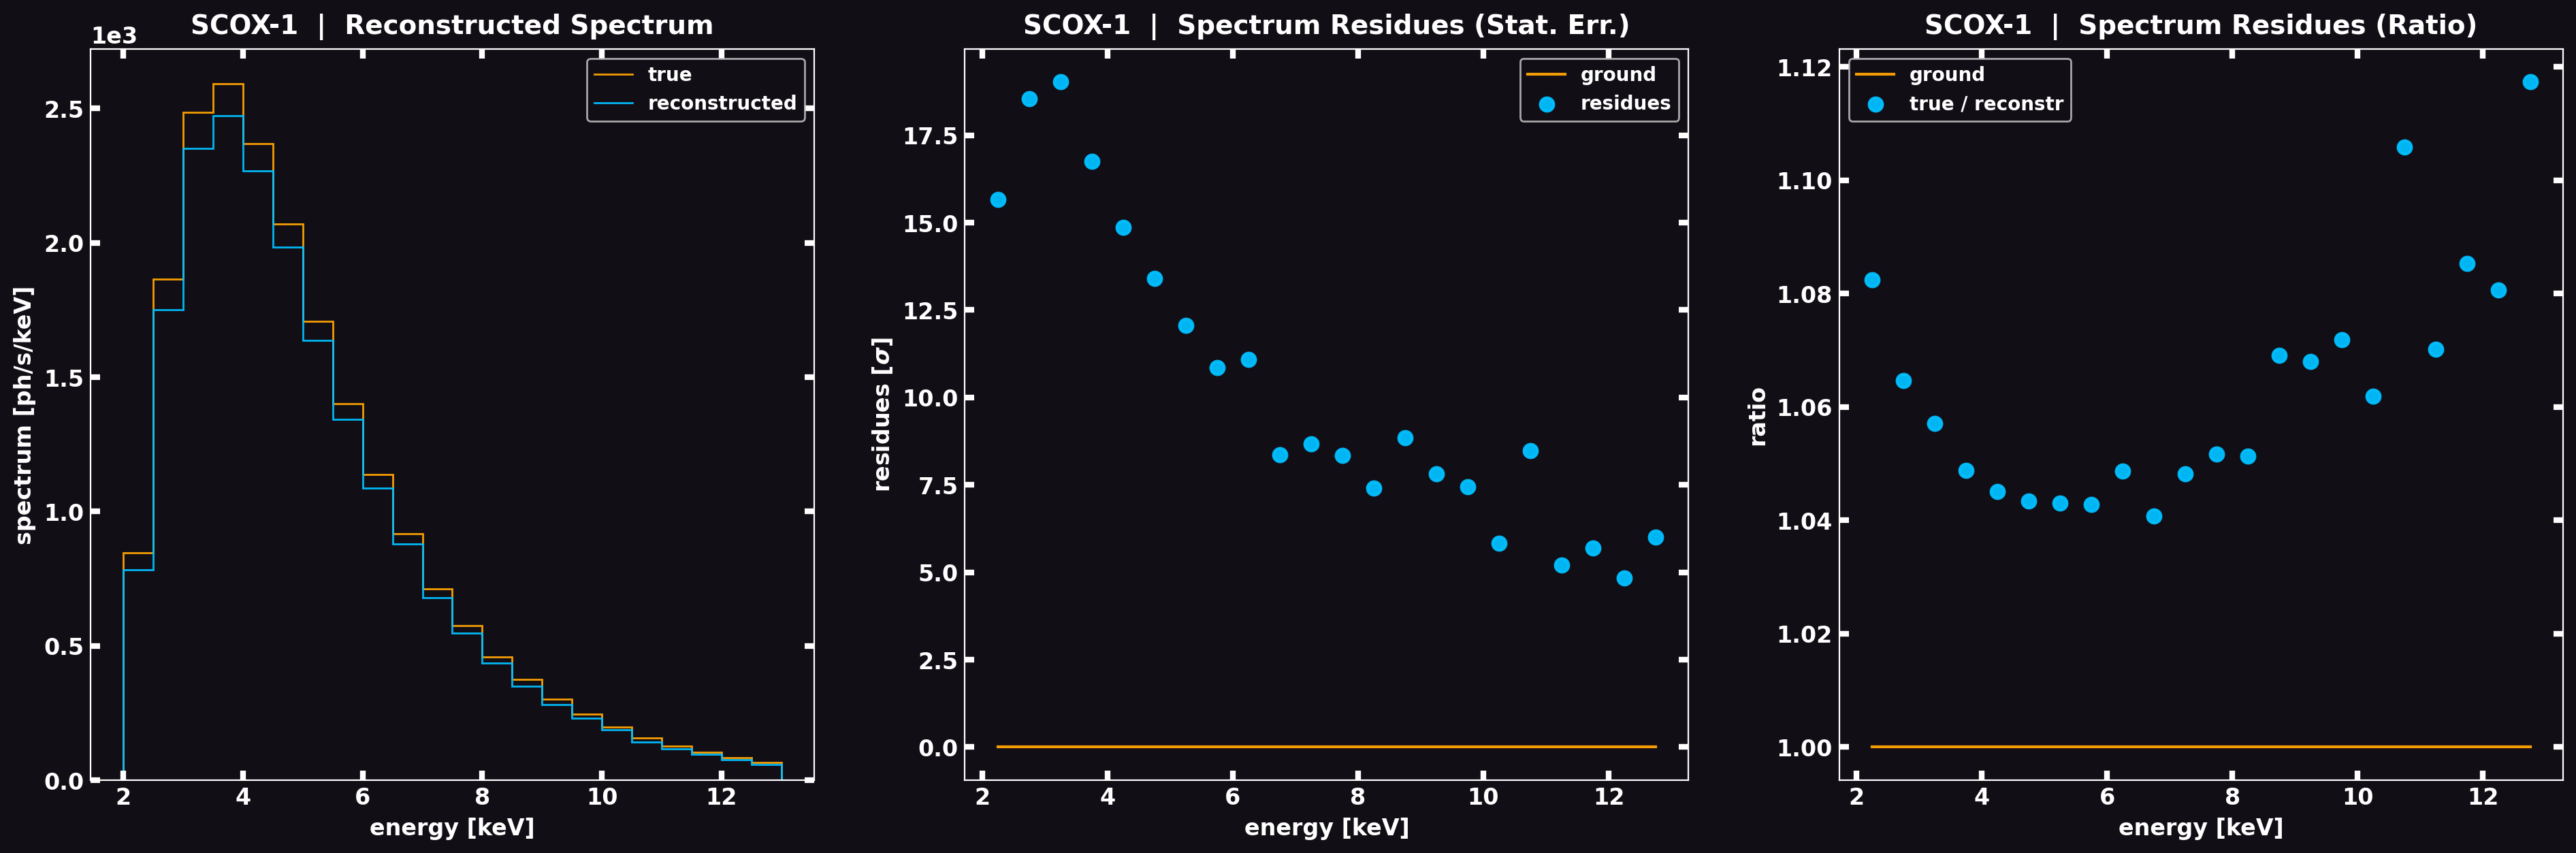

In [13]:
ds.plot(
    dmaps=(
        ds.map4plot(
            arrs=(true_spectr, spectra[:, 0]),
            title='SCOX-1  |  Reconstructed Spectrum',
            x=ebins,
            xlabel='energy [keV]',
            ylabel='spectrum [ph/s/keV]',
            labels=('true', 'reconstructed'),
            style='stairs',
            color=('Orange', 'DeepSkyBlue'),
            # yscale='log',
        ),
        ds.map4plot(
            arrs=(np.zeros_like(true_spectr), (true_cts - iros_cts[:, 0]) / np.sqrt(true_cts)),
            title='SCOX-1  |  Spectrum Residues (Stat. Err.)',
            x=ebins[:-1] + np.diff(ebins) / 2,
            xlabel='energy [keV]',
            ylabel='residues [$\\sigma$]',
            labels=('ground', 'residues'),
            style=('plot', 'scatter'),
            color=('Orange', 'DeepSkyBlue'),
        ),
        ds.map4plot(
            arrs=(np.ones_like(true_spectr), true_cts / iros_cts[:, 0]),
            title='SCOX-1  |  Spectrum Residues (Ratio)',
            x=ebins[:-1] + np.diff(ebins) / 2,
            xlabel='energy [keV]',
            ylabel='ratio',
            labels=('ground', 'true / reconstr'),
            style=('plot', 'scatter'),
            color=('Orange', 'DeepSkyBlue'),
        ),
    ),
    ncols=3,
    # save_to=f'{OUT_RESULTS_PATH}/{DATA_ID}_spectrs.png',
)